# 07 - Model comparison

Evaluates every model on the same test period with common metrics, forecast plots and error diagnostics, comparing each against the **strongest benchmark** rather than only against the other advanced models.

Forecasts come from `outputs/forecasts/all_forecasts.csv`, so nothing is refitted.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data, evaluation, plotting

config.ensure_dirs()

hourly = data.load_hourly_data()
y = hourly[config.TARGET].asfreq("h")
train, test = data.train_test_split_series(y, test_steps=config.TEST_STEPS)

saved = pd.read_csv(config.FORECAST_DIR / "all_forecasts.csv",
                    index_col=0, parse_dates=True)
actual = saved["actual"]
forecasts = {c: saved[c] for c in saved.columns if c != "actual"}

assert actual.index.equals(test.index), "saved forecasts must match the test period"

print(f"{len(forecasts)} models over {len(actual)} test hours")
print(f"Test period: {actual.index.min()} to {actual.index.max()}")
print("Models:", ", ".join(forecasts))

8 models over 336 test hours
Test period: 2016-05-13 19:00:00 to 2016-05-27 18:00:00
Models: mean, naive, seasonal_naive_daily, seasonal_naive_weekly, drift, sarimax, feature_model, foundation_model


## 1. Evaluation design

**Element** : **Choice**

**Target:** `Appliances`, hourly mean (Wh)

**Horizon:** 24 hours

**Test period:** final 14 days (336 hours)

**Metrics:** MAE, RMSE, MASE, Bias

**Scheme:** rolling origin, 14 blocks of 24 hours

All models are scored on identical timestamps. MASE below 1 beats the in-sample daily seasonal naive.

**One asymmetry.** The benchmarks, SARIMAX and the foundation model forecast in rolling blocks, so their first steps are only an hour or two ahead. The feature model predicts every row a full 24 hours ahead. Section 5 separates the two effects.

## 2. Accuracy metrics

In [2]:
results = evaluation.evaluate_all(
    forecasts, actual, train, seasonality=config.DAILY_PERIOD)
results.round(3)

,model,MAE,RMSE,MASE,Bias
0,foundation_model,34.268,68.087,0.641,-16.569
1,feature_model,35.384,62.033,0.662,-2.373
2,sarimax,36.255,64.736,0.679,-6.325
3,seasonal_naive_weekly,43.457,81.409,0.813,-13.160
4,seasonal_naive_daily,48.309,85.565,0.904,1.751
5,mean,50.258,74.938,0.941,-3.287
6,naive,85.551,110.390,1.601,50.977
7,drift,85.802,110.679,1.606,51.368


In [3]:
baseline = evaluation.strongest_benchmark(results)
print(f"Strongest benchmark: {baseline['model']}")
print(f"  MAE  {baseline['MAE']:.3f}")
print(f"  RMSE {baseline['RMSE']:.3f}")
print(f"  MASE {baseline['MASE']:.3f}")

Strongest benchmark: seasonal_naive_weekly
  MAE  43.457
  RMSE 81.409
  MASE 0.813


Saved figure to D:\UK ass\outputs\figures\metric_comparison.png


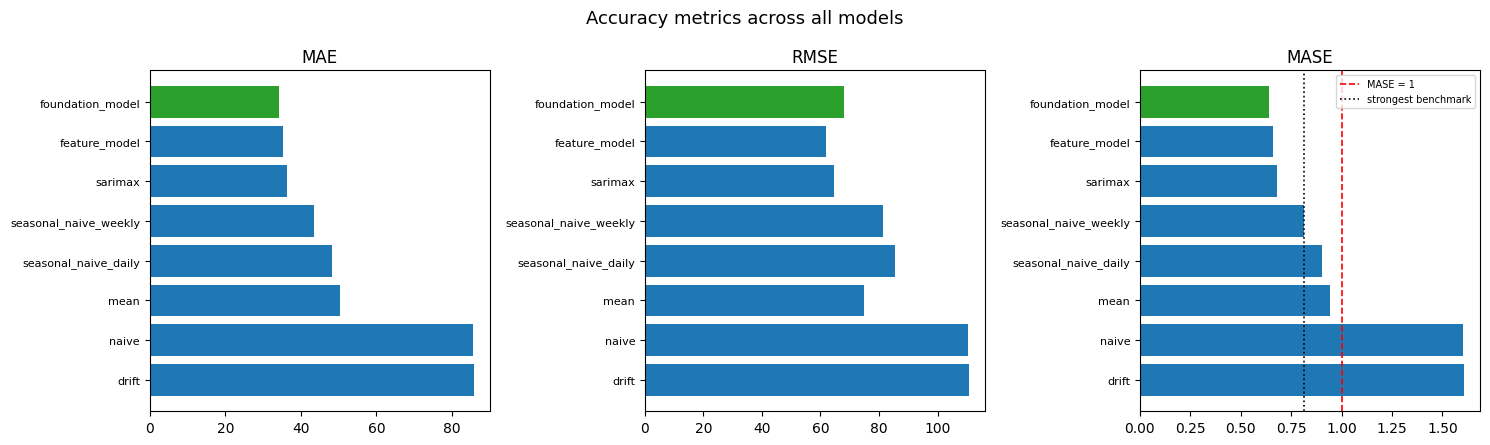

In [4]:
fig = plotting.plot_metric_comparison(
    results, baseline_mase=baseline["MASE"],
    title="Accuracy metrics across all models")
plotting.save_fig(fig, config.FIGURE_DIR / "metric_comparison.png")
plt.show()

**MAE and RMSE don't agree.** `mean` has a *lower* RMSE than the weekly seasonal naive despite a much worse MAE. A flat forecast never errs catastrophically, and RMSE squares errors so it rewards that caution. Hence reporting both.

## 3. Comparison against the strongest benchmark

The question that matters is not whether the complex models beat each other, but whether they beat the best simple one.

In [5]:
skill = evaluation.skill_scores(results, baseline_model=baseline["model"])
skill.round(2)

,model,MAE_improvement_%,RMSE_improvement_%,MASE_improvement_%,beats_benchmark
0,foundation_model,21.15,16.36,21.15,True
1,feature_model,18.58,23.80,18.58,True
2,sarimax,16.57,20.48,16.57,True
3,seasonal_naive_weekly,0.00,0.00,0.00,False
4,seasonal_naive_daily,-11.16,-5.10,-11.16,False
5,mean,-15.65,7.95,-15.65,False
6,naive,-96.86,-35.60,-96.86,False
7,drift,-97.44,-35.95,-97.44,False


Saved figure to D:\UK ass\outputs\figures\skill_scores.png


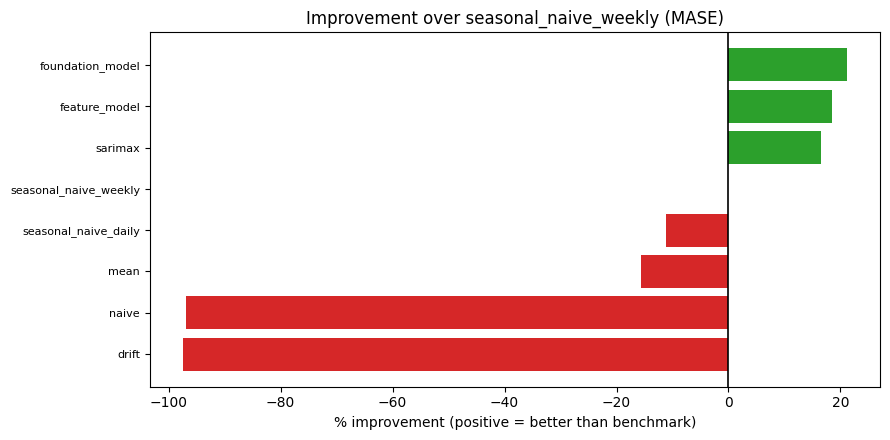

In [6]:
fig = plotting.plot_skill_scores(
    skill, title=f"Improvement over {baseline['model']} (MASE)")
plotting.save_fig(fig, config.FIGURE_DIR / "skill_scores.png")
plt.show()

Three models clear the benchmark and three fall below it. The MAE and MASE improvements are identical because MASE divides MAE by a constant scale, so it cancels, a consistency check on the metric code rather than a coincidence.

Note the **daily** seasonal naive does not beat the weekly one, and `naive` and `drift` are about twice as bad as the benchmark. Appliance use follows weekly routines, not the most recent reading.

## 4. Forecast plots

Saved figure to D:\UK ass\outputs\figures\forecast_comparison.png


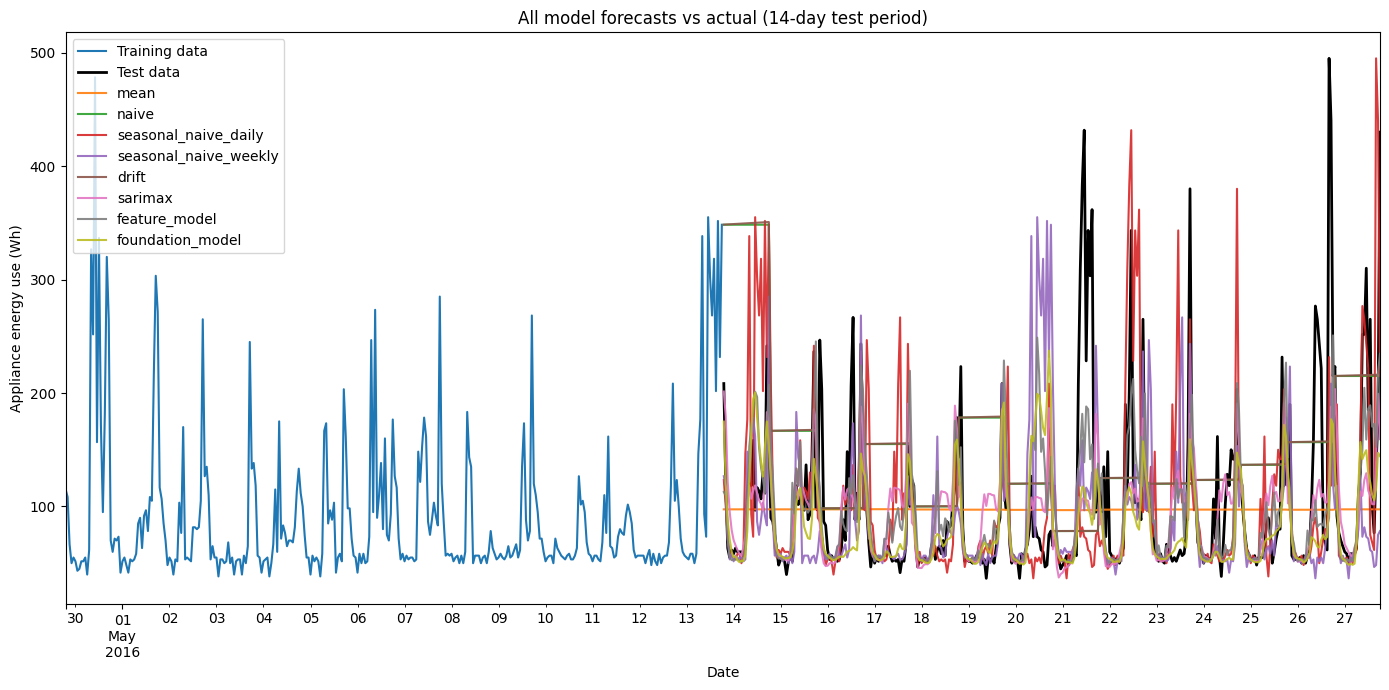

In [7]:
fig = plotting.plot_forecasts(
    train, actual, saved,
    title="All model forecasts vs actual (14-day test period)")
plotting.save_fig(fig, config.FIGURE_DIR / "forecast_comparison.png")
plt.show()

Saved figure to D:\UK ass\outputs\figures\07_leading_models_detail.png


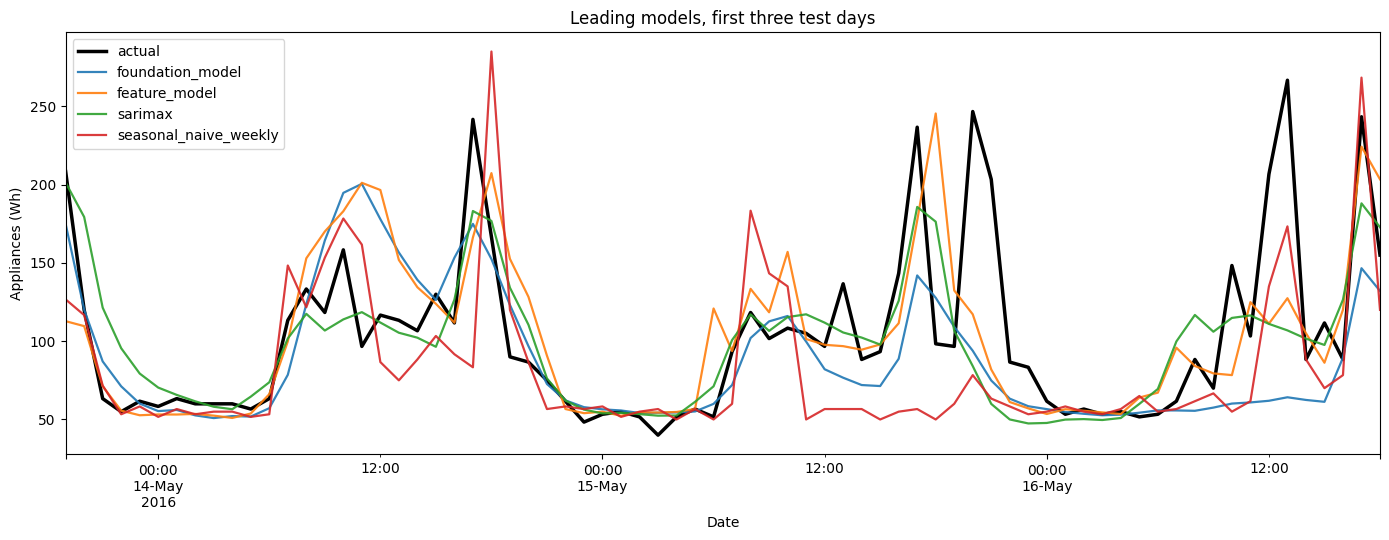

In [8]:
# The leading models over the first three test days, where the shapes
# are readable rather than overlapping.
window = slice(0, 72)
leaders = ["foundation_model", "feature_model", "sarimax", "seasonal_naive_weekly"]

fig, ax = plt.subplots(figsize=(14, 5.5))
actual.iloc[window].plot(ax=ax, color="black", linewidth=2.5, label="actual")
for name in leaders:
    saved[name].iloc[window].plot(ax=ax, linewidth=1.6, alpha=0.9, label=name)
ax.set_title("Leading models, first three test days")
ax.set_ylabel("Appliances (Wh)")
ax.set_xlabel("Date")
ax.legend()
fig.tight_layout()
plotting.save_fig(fig, config.FIGURE_DIR / "07_leading_models_detail.png")
plt.show()

Every model tracks the daily shape but under-shoots the sharp evening peaks. That's the dominant failure mode here: demand is spiky and event-driven, and all four approaches smooth it.

## 5. Error diagnostics

Aggregate metrics hide *where* and *when* models fail.

Saved figure to D:\UK ass\outputs\figures\error_diagnostics.png


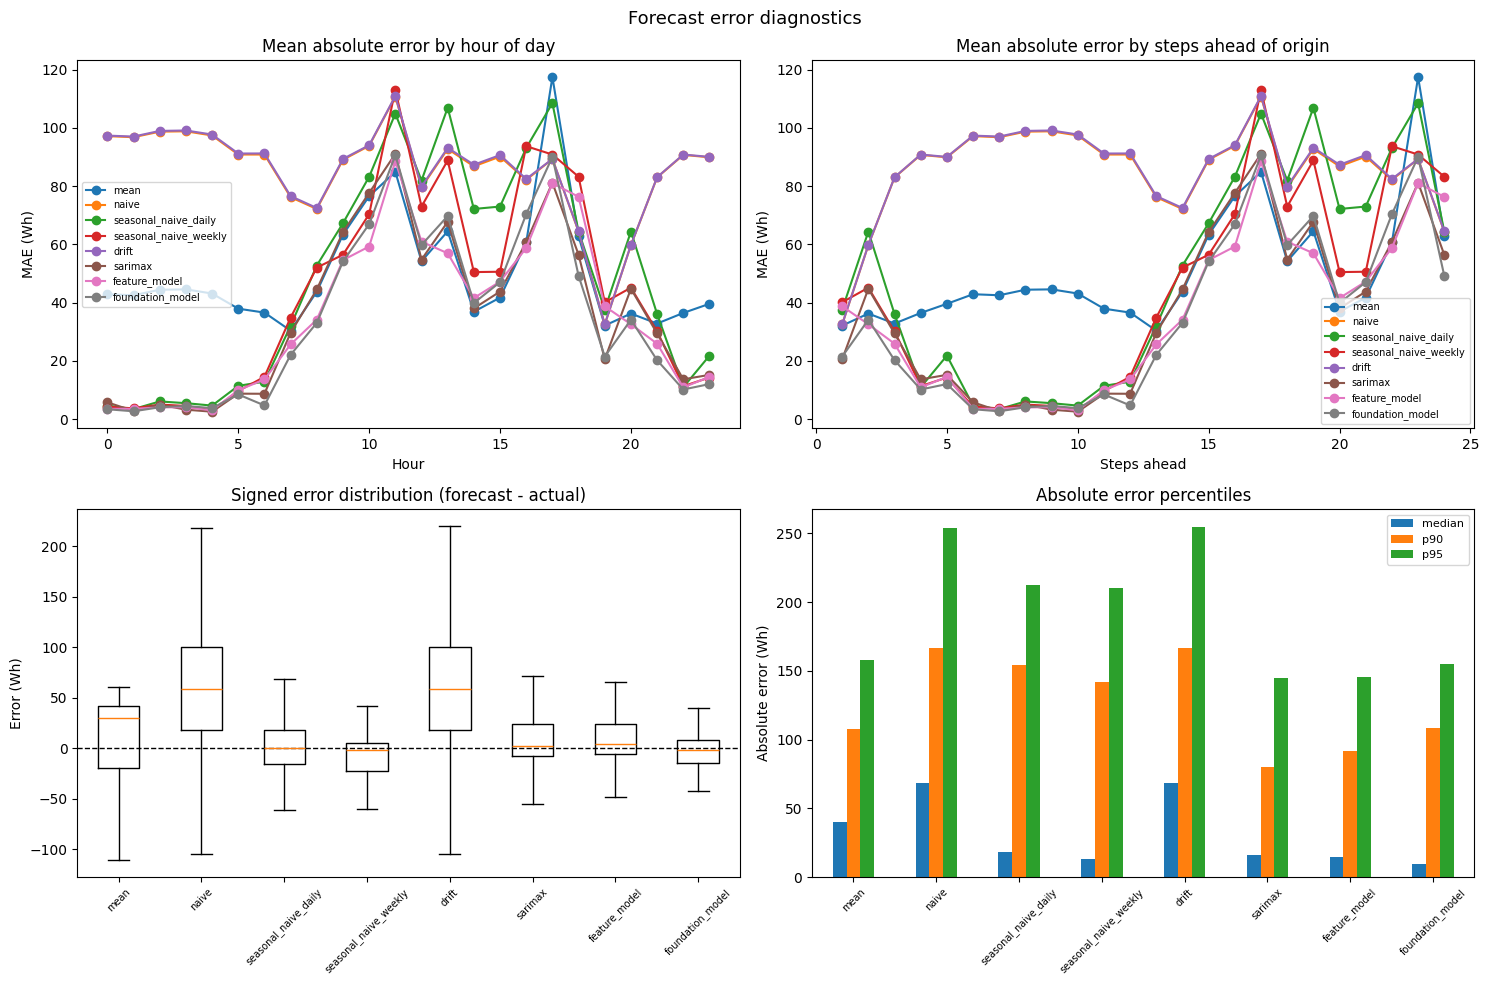

In [9]:
errors = evaluation.error_frame(forecasts, actual)
hourly_errors = evaluation.error_by_hour(forecasts, actual)
step_errors = evaluation.error_by_step_ahead(
    forecasts, actual, horizon=config.HORIZON)
summary = evaluation.error_summary(forecasts, actual)

fig = plotting.plot_error_diagnostics(
    errors, hourly_errors, step_errors, summary)
plotting.save_fig(fig, config.FIGURE_DIR / "error_diagnostics.png")
plt.show()

### 5a. Typical error versus worst-case error

In [10]:
summary.round(2)

,median,p75,p90,p95,max
mean,39.78,45.88,107.65,157.53,397.88
naive,68.33,106.67,166.67,253.75,353.33
seasonal_naive_daily,18.33,58.33,154.17,212.50,360.00
seasonal_naive_weekly,13.33,44.17,141.67,210.00,405.00
drift,68.50,107.19,166.73,254.90,353.21
sarimax,15.90,46.13,79.96,144.77,372.08
feature_model,14.74,45.09,91.93,145.60,390.29
foundation_model,9.80,31.59,108.50,154.67,392.03


The most informative table here. The foundation model has the **lowest median error** by a wide margin but the **worst 90th percentile** of the three advanced models. SARIMAX is the opposite: mediocre typically, most reliable when things go wrong.

That's why the foundation model wins on MAE and loses on RMSE. Neither metric is wrong, they answer different questions.

### 5b. When do models fail?

Saved figure to D:\UK ass\outputs\figures\07_error_by_hour.png


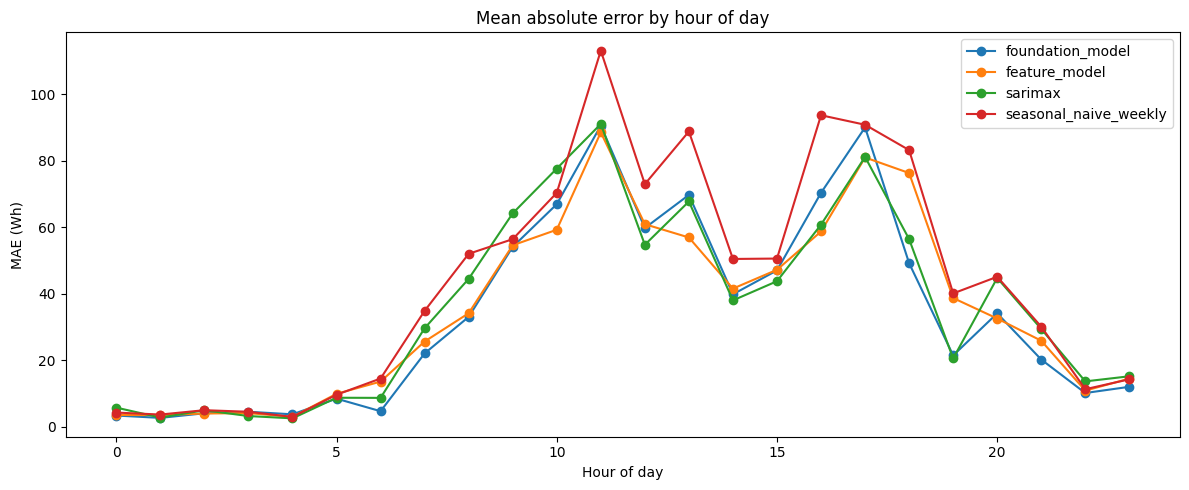

Hardest hour to forecast: 11:00
Easiest hour to forecast: 1:00


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
for name in leaders:
    hourly_errors[name].plot(ax=ax, marker="o", label=name)
ax.set_title("Mean absolute error by hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("MAE (Wh)")
ax.legend()
fig.tight_layout()
plotting.save_fig(fig, config.FIGURE_DIR / "07_error_by_hour.png")
plt.show()

peak_hour = hourly_errors.mean(axis=1).idxmax()
quiet_hour = hourly_errors.mean(axis=1).idxmin()
print(f"Hardest hour to forecast: {peak_hour}:00")
print(f"Easiest hour to forecast: {quiet_hour}:00")

### 5c. Error by position within the forecast block

**A caveat first.** The test period is 14 aligned 24-hour blocks, so step 1 is always 19:00 and step 24 always 18:00. Step position and hour of day are the same variable, and these numbers are the previous section's re-indexed. A rising profile is **not** evidence of decay with forecast distance.

What it does support is a **between-model** comparison at a fixed step. Separating horizon from time of day would need origins advancing by less than 24 hours, which we note as a limitation.

Saved figure to D:\UK ass\outputs\figures\07_error_by_step.png


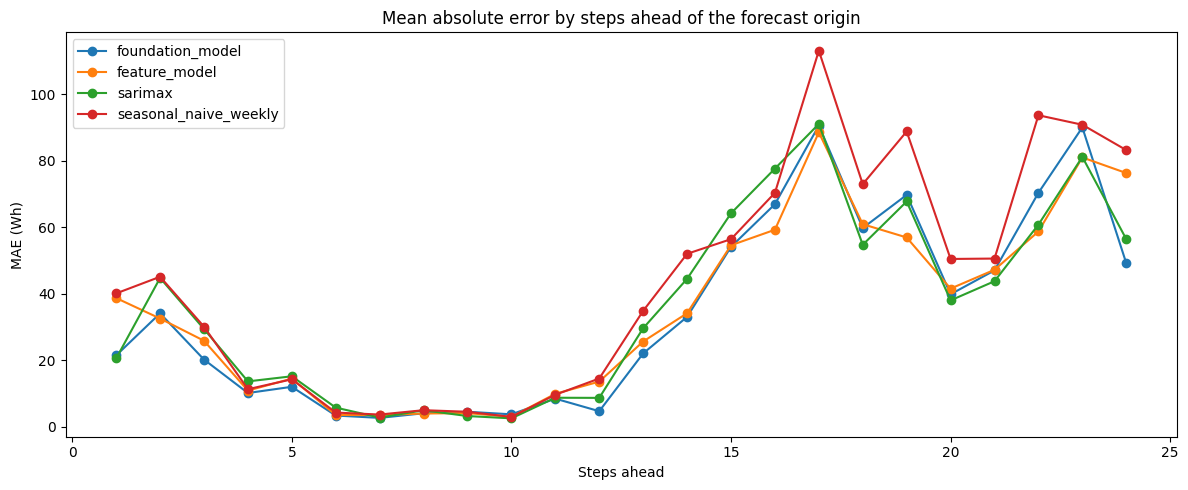

,foundation_model,feature_model,sarimax,seasonal_naive_weekly
step_ahead,,,,
1,21.47,38.72,20.55,40.12
12,4.70,13.60,8.70,14.52
24,49.21,76.32,56.43,83.21


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for name in leaders:
    step_errors[name].plot(ax=ax, marker="o", label=name)
ax.set_title("Mean absolute error by steps ahead of the forecast origin")
ax.set_xlabel("Steps ahead")
ax.set_ylabel("MAE (Wh)")
ax.legend()
fig.tight_layout()
plotting.save_fig(fig, config.FIGURE_DIR / "07_error_by_step.png")
plt.show()

step_errors.loc[[1, 12, 24], leaders].round(2)



**foundation_model(MAE at step 24):** 49.21

**sarimax(MAE at step 24):** 56.43

**feature_model(MAE at step 24):**  76.32

**seasonal_naive_weekly(MAE at step 24):** 83.21

The foundation model leads here as it does overall, so its advantage isn't an artefact of the scheme.

**But SARIMAX and the feature model swap places**, which the headline table hides. Over the full period the feature model is slightly ahead (35.38 vs 36.26), yet at equal horizon SARIMAX is clearly better. The overall figure is confounded by the horizon asymmetry, and the step-24 figure rests on 14 observations. Fair conclusion: the two are **hard to separate**.

### 5d. Is any structure left in the errors?

In [13]:
autocorr = evaluation.residual_autocorrelation(
    forecasts, actual, lags=(1, 24, 168))
autocorr.round(3)

,lag_1,lag_24,lag_168
mean,0.641,0.381,0.349
naive,0.787,0.267,-0.159
seasonal_naive_daily,0.547,-0.299,-0.164
seasonal_naive_weekly,0.638,0.062,-0.418
drift,0.788,0.266,-0.162
sarimax,0.557,0.139,0.001
feature_model,0.410,-0.027,-0.107
foundation_model,0.592,0.039,-0.239


Every model keeps substantial lag-1 autocorrelation, expected at this horizon since consecutive hours aren't re-forecast independently.

The lag-24 and lag-168 columns say more. The feature model leaves nothing at lag 24 (-0.03) and SARIMAX nothing at lag 168 (0.00), so both absorbed the cycle they were built for. The daily seasonal naive shows a strong *negative* lag-24 value, over- and under-shooting on alternating days. `mean` leaves large positive values at both lags, which is unexploited structure.

## 6. Bias

Saved figure to D:\UK ass\outputs\figures\07_bias.png


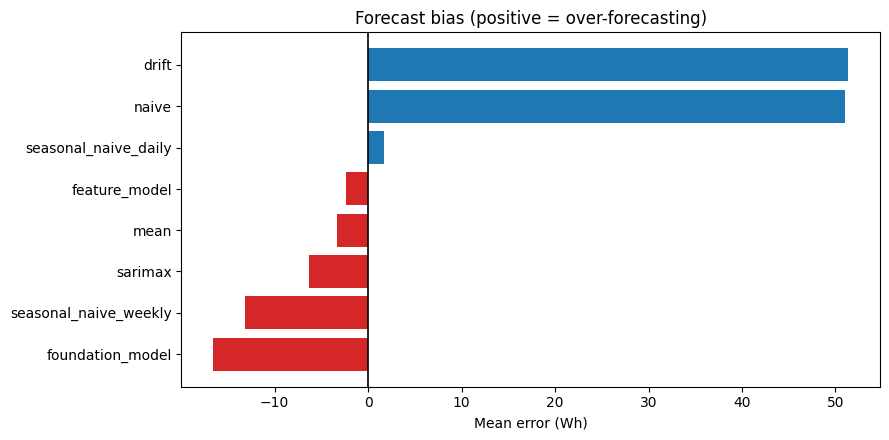

model
foundation_model        -16.57
seasonal_naive_weekly   -13.16
sarimax                  -6.33
mean                     -3.29
feature_model            -2.37
seasonal_naive_daily      1.75
naive                    50.98
drift                    51.37
Name: Bias, dtype: float64

In [14]:
bias = results.set_index("model")["Bias"].sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["tab:red" if v < 0 else "tab:blue" for v in bias]
ax.barh(bias.index, bias.values, color=colors)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_title("Forecast bias (positive = over-forecasting)")
ax.set_xlabel("Mean error (Wh)")
fig.tight_layout()
plotting.save_fig(fig, config.FIGURE_DIR / "07_bias.png")
plt.show()

bias.round(2)

The foundation model has the largest negative bias of the leading three, consistent with hedging toward the typical level and clipping peaks. The feature model is closest to unbiased. `naive` and `drift` over-forecast because the last training hours were high and they carry that forward.

## 7. Save outputs

In [15]:
results.to_csv(config.METRICS_DIR / "model_comparison.csv", index=False)
skill.to_csv(config.METRICS_DIR / "skill_vs_benchmark.csv", index=False)
summary.to_csv(config.METRICS_DIR / "error_percentiles.csv")
hourly_errors.to_csv(config.METRICS_DIR / "error_by_hour.csv")
step_errors.to_csv(config.METRICS_DIR / "error_by_step_ahead.csv")
autocorr.to_csv(config.METRICS_DIR / "error_autocorrelation.csv")

print("Saved comparison metrics and diagnostics.")

Saved comparison metrics and diagnostics.


## Summary

**Ranking (MASE).** foundation 0.641 < feature 0.662 < SARIMAX 0.679 < weekly seasonal naive 0.813 < daily seasonal naive 0.904 < mean 0.941 < naive 1.601 < drift 1.606.

**Against the weekly seasonal naive:** foundation +21% MAE/MASE and +16% RMSE, feature +19% and +24%, SARIMAX +17% and +20%. All three clear it meaningfully; no other benchmark does.

**But the three are close**, about 3 points of MASE, and the ordering isn't stable. At equal horizon SARIMAX overtakes the feature model, reversing the headline table. Only the foundation model's lead holds under both views.

| Model | Strength | Weakness |
|---|---|---|
| Foundation (Chronos) | best typical accuracy, no fitting needed | worst tail errors, largest bias, needs torch |
| Feature-based (RF) | best RMSE, nearly unbiased, cleanest residuals | needs a feature pipeline and retraining |
| SARIMAX | most reliable in the tail, exact intervals | slowest to fit, weakest typical accuracy |

**Common failure mode.** Every model under-predicts the sharp evening peaks. Further gains would come from modelling the spike process, not refining the daily cycle.